##### Since the images are random, different sizes and channels so need to be formated the same way.
##### OpenCV and Mediapipe will help the face detection and process the images to be in the same format

In [1]:
#import Libraries
import cv2
import os
import sys
import mediapipe as mp
import urllib.request
import warnings
import numpy as np
import matplotlib.pyplot as plt
from deepface import DeepFace
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from PIL import Image

In [2]:
warnings.filterwarnings('ignore')

In [3]:
# Config
INPUT_DIR  = 'dataset'
OUTPUT_DIR = 'dataset_cleaned'
IMG_SIZE   = (224, 224)
MODEL_PATH = os.path.join(os.getcwd(), 'blaze_face_short_range.tflite')
MODEL_URL  = 'https://storage.googleapis.com/mediapipe-models/face_detector/blaze_face_short_range/float16/1/blaze_face_short_range.tflite'
VALID_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

if not os.path.exists(MODEL_PATH):
    urllib.request.urlretrieve(MODEL_URL, MODEL_PATH)

BaseOptions         = mp.tasks.BaseOptions
FaceDetector        = mp.tasks.vision.FaceDetector
FaceDetectorOptions = mp.tasks.vision.FaceDetectorOptions

options = FaceDetectorOptions(
    base_options=BaseOptions(model_asset_path=MODEL_PATH),
    min_detection_confidence=0.5
)

os.makedirs(OUTPUT_DIR, exist_ok=True)

with FaceDetector.create_from_options(options) as detector:
    for person_name in os.listdir(INPUT_DIR):
        person_path = os.path.join(INPUT_DIR, person_name)
        if not os.path.isdir(person_path):
            continue

        save_path = os.path.join(OUTPUT_DIR, person_name)
        os.makedirs(save_path, exist_ok=True)

        saved, skipped = 0, 0

        for img_name in os.listdir(person_path):
            if os.path.splitext(img_name)[1].lower() not in VALID_EXTENSIONS:
                continue

            img_path = os.path.join(person_path, img_name)

            try:
                img = cv2.imread(img_path)
                if img is None:
                    continue

                h, w = img.shape[:2]
                img_rgb  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
                detection_result = detector.detect(mp_image)

                if detection_result.detections:
                    bbox = detection_result.detections[0].bounding_box
                    x1 = max(0, int(bbox.origin_x))
                    y1 = max(0, int(bbox.origin_y))
                    x2 = min(w, int(bbox.origin_x + bbox.width))
                    y2 = min(h, int(bbox.origin_y + bbox.height))
                    face_crop = img[y1:y2, x1:x2]
                    if face_crop.size > 0:
                        face_resized = cv2.resize(face_crop, IMG_SIZE)
                        cv2.imwrite(os.path.join(save_path, img_name), face_resized)
                        saved += 1
                else:
                    skipped += 1

            except Exception as e:
                pass  # silently skip errors too

# Restore output
sys.stdout = sys.__stdout__
sys.stderr = sys.__stderr__

print("Done! Cleaned dataset saved to 'dataset_cleaned'")

I0000 00:00:1780648320.340324 2855777 init-domain.cc:128] Fiber init: default domain = pthread, concurrency = 15, prefix = pthread-default
I0000 00:00:1780648320.388537 2855777 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4 Pro
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1780648320.389457 2855780 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Done! Cleaned dataset saved to 'dataset_cleaned'
Setup done!
Error: Confirm that dataset_cleaned/zach/zach1.jpg exists
Evaluating 10 people...



##### After processing the images to the standard format, we will jump into face recogntion taskS

In [3]:
# Config
DATA_DIR   = 'dataset_cleaned'
MODEL_NAME = 'Facenet'
METRIC     = 'cosine'
THRESHOLD  = 0.40

sys.stdout = sys.__stdout__
sys.stderr = sys.__stderr__
print("Setup done!")

Setup done!

Top matches:
  zach                      distance: 0.352
  pm_dr_abiy                distance: 0.392

Top matches:
  robert_oppenheimer        distance: 0.000
  robert_oppenheimer        distance: 0.119
  robert_oppenheimer        distance: 0.127

Top matches:
  robert_oppenheimer        distance: 0.000
  robert_oppenheimer        distance: 0.156
  robert_oppenheimer        distance: 0.188

Top matches:
  michael_jackson           distance: 0.030
  michael_jackson           distance: 0.201
  michael_jackson           distance: 0.207

Top matches:
  michael_jackson           distance: 0.021
  michael_jackson           distance: 0.190
  michael_jackson           distance: 0.198

Top matches:
  albert_einstein           distance: 0.000
  president_trump           distance: 0.104
  zach                      distance: 0.369

Top matches:
  albert_einstein           distance: 0.000
  albert_einstein           distance: 0.189
  albert_einstein           distance: 0.201

Top match

In [4]:
# Inference on a single image
def predict_face(img_path, show=True):
    sys.stdout = open(os.devnull, 'w')
    sys.stderr = open(os.devnull, 'w')

    try:
        results = DeepFace.find(
            img_path=img_path,
            db_path=DATA_DIR,
            model_name=MODEL_NAME,
            distance_metric=METRIC,
            enforce_detection=False,
            silent=True,
        )

        df = results[0]

        if df.empty:
            sys.stdout = sys.__stdout__
            sys.stderr = sys.__stderr__
            return None, None

        df = df.sort_values('distance').reset_index(drop=True)
        best        = df.iloc[0]
        person_name = os.path.basename(os.path.dirname(best['identity']))
        distance    = best['distance']

        sys.stdout = sys.__stdout__
        sys.stderr = sys.__stderr__

        if distance > THRESHOLD:
            print(f"Unknown (closest: {person_name}, distance: {distance:.3f})")
            return None, distance

        if show:
            img = Image.open(img_path)
            plt.figure(figsize=(4, 4))
            plt.imshow(img)
            plt.title(f"{person_name}\ndistance: {distance:.3f}", fontsize=13)
            plt.axis('off')
            plt.tight_layout()
            plt.show()

            print(f"\nTop matches:")
            for _, row in df.head(3).iterrows():
                name = os.path.basename(os.path.dirname(row['identity']))
                print(f"  {name:<25} distance: {row['distance']:.3f}")

        return person_name, distance

    except Exception as e:
        sys.stdout = sys.__stdout__
        sys.stderr = sys.__stderr__
        print(f"Error: {e}")
        return None, None

In [5]:
# Evaluation
def evaluate(data_dir, skip_every=3):
    y_true, y_pred = [], []
    class_names = sorted([
        c for c in os.listdir(data_dir)
        if os.path.isdir(os.path.join(data_dir, c))
    ])

    print(f"Evaluating {len(class_names)} people...\n")

    for person_name in class_names:
        person_path = os.path.join(data_dir, person_name)
        images = [f for f in os.listdir(person_path)
                  if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

        for img_name in images[::skip_every]:
            img_path = os.path.join(person_path, img_name)
            predicted, _ = predict_face(img_path, show=False)
            y_true.append(person_name)
            y_pred.append(predicted if predicted else 'unknown')

    print("Classification Report:")
    print(classification_report(y_true, y_pred, labels=class_names))

    cm = confusion_matrix(y_true, y_pred, labels=class_names)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=class_names,
                yticklabels=class_names,
                cmap='Blues')
    plt.title('Confusion Matrix')
    plt.ylabel('True')
    plt.xlabel('Predicted')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

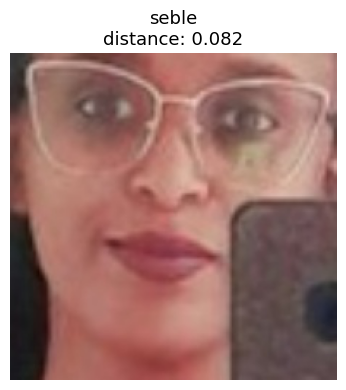

('seble', np.float64(0.082045))

In [14]:
# Run inference
predict_face('dataset_cleaned/seble/photo_2026-06-04 20.45.06.jpeg')

In [ ]:
# Run evaluation
evaluate(DATA_DIR)

## 1. Advanced Machine Learning Pipeline & Hyperparameter Tuning
In this section, we extract raw FaceNet embeddings for all images in our cleaned dataset and build Machine Learning classifiers (SVM and KNN) on top of them.


In [ ]:
import pandas as pd
import numpy as np
from deepface import DeepFace
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import plotly.express as px
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import joblib
import time
import os

DATA_DIR = 'dataset_cleaned'
MODEL_NAME = 'Facenet'

print("Extracting embeddings for the dataset...")
data = []
labels = []
class_names = sorted([c for c in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, c))])

for person in class_names:
    person_path = os.path.join(DATA_DIR, person)
    for img_name in os.listdir(person_path):
        if not img_name.lower().endswith(('.jpg', '.jpeg', '.png')): continue
        img_path = os.path.join(person_path, img_name)
        try:
            # Extract 128D FaceNet embedding
            embedding_objs = DeepFace.represent(img_path=img_path, model_name=MODEL_NAME, enforce_detection=False)
            if embedding_objs:
                embedding = embedding_objs[0]['embedding']
                data.append(embedding)
                labels.append(person)
        except Exception as e:
            print(f"Error on {img_path}: {e}")

X = np.array(data)
y = np.array(labels)
print(f"Extracted {len(X)} embeddings for {len(class_names)} people.")



## 2. SVM Hyperparameter Tuning & Training
We will train a Support Vector Machine (SVM) and tune its `C` parameter.


In [ ]:
# Split dataset (using a small test_size or stratified k-fold since the dataset is small)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Tuning SVM Classifier...")
svm_param_grid = {'C': [0.1, 1, 10, 100], 'kernel': ['linear', 'rbf']}
svm_grid = GridSearchCV(SVC(probability=True), svm_param_grid, cv=3)
svm_grid.fit(X_train, y_train)

best_svm = svm_grid.best_estimator_
print(f"Best SVM Parameters: {svm_grid.best_params_}")

svm_pred = best_svm.predict(X_test)
svm_acc = accuracy_score(y_test, svm_pred)
print(f"SVM Test Accuracy: {svm_acc*100:.2f}%")



## 3. KNN Hyperparameter Tuning & Analysis
Let's analyze how the K parameter affects our KNN model.


In [ ]:
print("Tuning KNN Classifier...")
knn_accuracies = []
k_values = [1, 2, 3, 4, 5]

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, metric='cosine')
    knn.fit(X_train, y_train)
    acc = accuracy_score(y_test, knn.predict(X_test))
    knn_accuracies.append(acc)

# Plot hyperparameter graph using Plotly
fig_knn = px.line(x=k_values, y=knn_accuracies, markers=True, 
                  title="KNN Accuracy vs K Value", 
                  labels={'x':'K (Number of Neighbors)', 'y':'Accuracy'})
fig_knn.show()

best_k = k_values[np.argmax(knn_accuracies)]
best_knn = KNeighborsClassifier(n_neighbors=best_k, metric='cosine')
best_knn.fit(X_train, y_train)
print(f"Best KNN Model has K={best_k} with accuracy {max(knn_accuracies)*100:.2f}%")



## 4. Inference Time Comparison
Let's compare the prediction speed of SVM vs KNN.


In [ ]:
# Inference time test
test_sample = X_test[0].reshape(1, -1)

# SVM Time
start = time.time()
best_svm.predict(test_sample)
svm_time = (time.time() - start) * 1000 # ms

# KNN Time
start = time.time()
best_knn.predict(test_sample)
knn_time = (time.time() - start) * 1000 # ms

fig_time = px.bar(x=['SVM', 'KNN'], y=[svm_time, knn_time], 
                  color=['SVM', 'KNN'],
                  title="Inference Time Comparison (milliseconds)",
                  labels={'x': 'Model', 'y': 'Time (ms)'})
fig_time.show()



## 5. Exporting the Best Model for the Streamlit App
We will save the SVM model since SVMs generally perform exceptionally well on FaceNet embeddings.


In [ ]:
model_export_path = "best_model.pkl"
joblib.dump(best_svm, model_export_path)
print(f"Saved the best model to {model_export_path} for production deployment!")



## 6. PCA and t-SNE Clustering Visualizations
Dimensionality reduction allows us to visualize the 128-dimensional embedding space in 2D and 3D.


In [ ]:
print("Performing PCA...")
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X)

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2', 'PC3'])
df_pca['Person'] = y

fig_pca_2d = px.scatter(df_pca, x='PC1', y='PC2', color='Person', 
                        title="2D PCA of FaceNet Embeddings",
                        hover_data=['Person'])
fig_pca_2d.show()

fig_pca_3d = px.scatter_3d(df_pca, x='PC1', y='PC2', z='PC3', color='Person', 
                           title="3D PCA of FaceNet Embeddings")
fig_pca_3d.update_traces(marker=dict(size=4))
fig_pca_3d.show()

print("Performing t-SNE...")
tsne = TSNE(n_components=2, perplexity=5, random_state=42)
X_tsne = tsne.fit_transform(X)

df_tsne = pd.DataFrame(X_tsne, columns=['Dim1', 'Dim2'])
df_tsne['Person'] = y

fig_tsne = px.scatter(df_tsne, x='Dim1', y='Dim2', color='Person', 
                      title="2D t-SNE of FaceNet Embeddings")
fig_tsne.show()



## 7. Confusion Matrix Heatmap
Let's look at where the SVM model makes errors.


In [ ]:
import plotly.figure_factory as ff

cm = confusion_matrix(y_test, svm_pred, labels=class_names)
fig_cm = ff.create_annotated_heatmap(z=cm, x=class_names, y=class_names, colorscale='Blues')
fig_cm.update_layout(title_text='SVM Confusion Matrix Heatmap',
                     xaxis_title="Predicted Label",
                     yaxis_title="True Label")
fig_cm.show()

